## 1. Boilerplate

In [1]:
import sys
sys.path.insert(0, "..")

import logging
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import torch
import torch.nn as nn

from src.models.gating_network import GatingMLP, GatingNetwork
from src.models.moe_ensemble import MOEEnsemble
from src.features.pipeline import build_features_for_split
from src.data.merge import merge_kenpom_with_matchups
from src.evaluation.metrics import compute_all_metrics, compute_logloss
from src.config import (
    FIRST_YEAR, LAST_YEAR, SKIP_YEARS, EXPERT_TYPES,
    GATING_HIDDEN_SIZES, GATING_DROPOUT, GATING_LR, GATING_EPOCHS, GATING_BATCH_SIZE,
)

sns.set_theme(style="whitegrid")
logging.basicConfig(level=logging.INFO)
pd.set_option("display.max_columns", 50)

print("Setup complete.")

Setup complete.


## 2. Generate Inner-CV Expert Predictions

In [2]:
merged_df = merge_kenpom_with_matchups()
all_seasons = [y for y in range(FIRST_YEAR, LAST_YEAR + 1) if y not in SKIP_YEARS]
test_seasons = [2024, 2025]
train_seasons = [y for y in all_seasons if y not in test_seasons]

moe = MOEEnsemble()
context_X, expert_preds, y = moe.generate_inner_cv_predictions(train_seasons, merged_df)

# Fill NaN in gating features (e.g. luck_delta can be NaN for early seasons)
nan_count = np.isnan(context_X).sum()
if nan_count > 0:
    print(f"Filling {nan_count} NaN values in context_X with 0")
    context_X = np.nan_to_num(context_X, nan=0.0)

print(f"Inner-CV shapes: context_X={context_X.shape}, expert_preds={expert_preds.shape}, y={y.shape}")

# Also train final experts + get test predictions
train_fs, test_fs = build_features_for_split(train_seasons, test_seasons, merged_df)
moe.train_experts(train_fs, val_fs=test_fs)
test_expert_preds = moe.get_expert_predictions(test_fs)

# One-hot encoded gating features for gating network (matches inner-CV encoding)
test_context_X = np.nan_to_num(moe._get_gating_features(test_fs), nan=0.0)

# Raw gating features for analysis/visualization
test_gating_raw = test_fs.X[test_fs.gating_features].copy()

print(f"Test shapes: test_context_X={test_context_X.shape}, test_expert_preds={test_expert_preds.shape}")
print(f"Gating features (one-hot encoded round): {test_context_X.shape[1]} dims")

INFO:src.data.kaggle_loader:Loading DEV table from /Users/austinsalter/Documents/Projects/March-Madness-MOE/data/raw/kenpom/DEV _ March Madness.csv
INFO:src.data.kaggle_loader:Loaded DEV table: 8315 rows, 24 seasons (2002–2025), 38 columns
INFO:src.data.kaggle_loader:Loading pomeroy ratings from /Users/austinsalter/Documents/Projects/March-Madness-MOE/data/cache/kenpom_pomeroy_ratings.parquet
INFO:src.data.kaggle_loader:Loaded pomeroy ratings: 8679 rows, 25 seasons
INFO:src.data.kaggle_loader:Pomeroy merge: 7607/8315 matched. 708 unmatched (mostly non-tournament): ['Miami', 'Pennsylvania', 'Little Rock', 'McNeese', 'IU Indianapolis', 'Sam Houston', 'Missouri State', 'Louisiana', 'Miami (OH)', 'Charleston']
INFO:src.data.kaggle_loader:Final KenPom dataset: 8314 rows, 43 columns, seasons 2002–2025
INFO:src.data.tournament_data:Dropping 63 First Four / play-in games
INFO:src.data.tournament_data:Loaded 1386 tournament matchups across 22 seasons (2003–2025)
INFO:src.data.merge:Merge comple

Filling 53 NaN values in context_X with 0
Inner-CV shapes: context_X=(1262, 9), expert_preds=(1262, 3), y=(1262,)


INFO:src.models.tree_expert:Trained seed_baseline expert: best_iteration=809, n_features=12, n_samples=1262
INFO:src.models.moe_ensemble:Trained expert: seed_baseline
INFO:src.models.tree_expert:Trained efficiency_delta expert: best_iteration=239, n_features=27, n_samples=1262
INFO:src.models.moe_ensemble:Trained expert: efficiency_delta
INFO:src.models.tree_expert:Trained uncertainty_calibration expert: best_iteration=7, n_features=13, n_samples=1262
INFO:src.models.moe_ensemble:Trained expert: uncertainty_calibration


Test shapes: test_context_X=(126, 9), test_expert_preds=(126, 3)
Gating features (one-hot encoded round): 9 dims


## 3. Train Default Gating

In [3]:
# Train/val split for gating experiments
from sklearn.model_selection import train_test_split

idx_train, idx_val = train_test_split(
    np.arange(len(y)), test_size=0.2, random_state=42, stratify=y,
)

ctx_train = torch.tensor(context_X[idx_train], dtype=torch.float32)
ctx_val = torch.tensor(context_X[idx_val], dtype=torch.float32)
ep_train = torch.tensor(expert_preds[idx_train], dtype=torch.float32)
ep_val = torch.tensor(expert_preds[idx_val], dtype=torch.float32)
y_train_t = torch.tensor(y[idx_train], dtype=torch.float32)
y_val_t = torch.tensor(y[idx_val], dtype=torch.float32)

criterion = nn.BCELoss()
patience = 20

# Train default gating network
mlp = GatingMLP(context_X.shape[1], n_experts=3,
                hidden_sizes=GATING_HIDDEN_SIZES, dropout=GATING_DROPOUT)
optimizer = torch.optim.Adam(mlp.parameters(), lr=GATING_LR)

train_losses = []
val_losses = []
best_val_loss = float("inf")
best_epoch = 0
best_state = None

for epoch in range(GATING_EPOCHS):
    # Train
    mlp.train()
    w = mlp(ctx_train)
    blend = (w * ep_train).sum(dim=1)
    blend = blend.clamp(1e-7, 1 - 1e-7)
    loss = criterion(blend, y_train_t)
    optimizer.zero_grad()
    loss.backward()
    optimizer.step()
    train_losses.append(loss.item())

    # Validate
    mlp.eval()
    with torch.no_grad():
        w_val = mlp(ctx_val)
        blend_val = (w_val * ep_val).sum(dim=1)
        blend_val = blend_val.clamp(1e-7, 1 - 1e-7)
        vl = criterion(blend_val, y_val_t).item()
    val_losses.append(vl)

    if vl < best_val_loss:
        best_val_loss = vl
        best_epoch = epoch
        best_state = {k: v.clone() for k, v in mlp.state_dict().items()}

    if epoch - best_epoch >= patience:
        print(f"Early stopping at epoch {epoch} (patience={patience})")
        break

mlp.load_state_dict(best_state)

print(f"Default gating: best_val_loss={best_val_loss:.6f} at epoch {best_epoch}")
print(f"  hidden_sizes={GATING_HIDDEN_SIZES}, dropout={GATING_DROPOUT}, lr={GATING_LR}")

# Show mean weights on validation set
mlp.eval()
with torch.no_grad():
    w_check = mlp(ctx_val).numpy()
for i, name in enumerate(EXPERT_TYPES):
    print(f"  {name}: mean_weight={w_check[:, i].mean():.4f}")

Default gating: best_val_loss=0.401697 at epoch 199
  hidden_sizes=[16, 8], dropout=0.2, lr=0.001
  seed_baseline: mean_weight=0.7063
  efficiency_delta: mean_weight=0.1466
  uncertainty_calibration: mean_weight=0.1471


## 4. Viz: Training Loss Curves

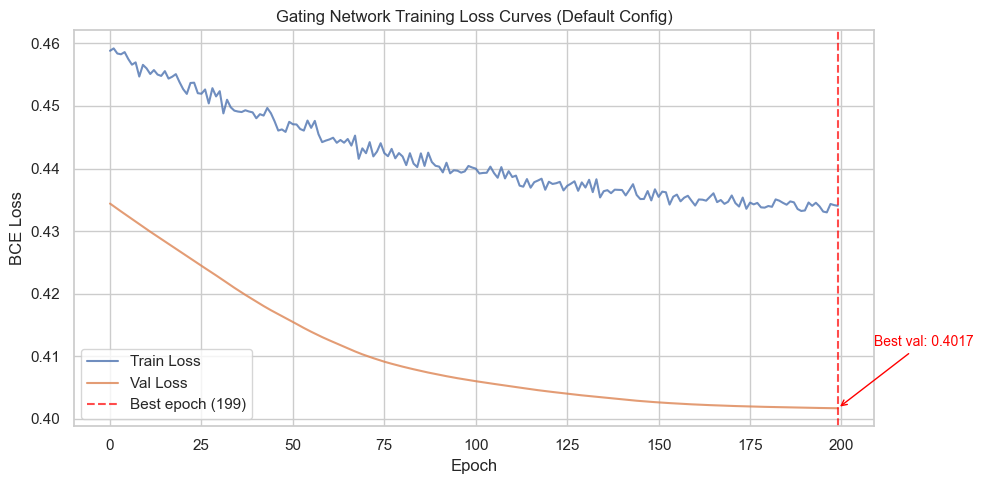

In [4]:
fig, ax = plt.subplots(figsize=(10, 5))
epochs_range = range(len(train_losses))
ax.plot(epochs_range, train_losses, label="Train Loss", alpha=0.8)
ax.plot(epochs_range, val_losses, label="Val Loss", alpha=0.8)
ax.axvline(x=best_epoch, color="red", linestyle="--", alpha=0.7, label=f"Best epoch ({best_epoch})")
ax.annotate(f"Best val: {best_val_loss:.4f}",
            xy=(best_epoch, best_val_loss),
            xytext=(best_epoch + 10, best_val_loss + 0.01),
            arrowprops=dict(arrowstyle="->", color="red"),
            fontsize=10, color="red")
ax.set_xlabel("Epoch")
ax.set_ylabel("BCE Loss")
ax.set_title("Gating Network Training Loss Curves (Default Config)")
ax.legend()
plt.tight_layout()
plt.show()

## 5. Architecture Search

In [5]:
arch_configs = [[8], [16, 8], [32, 16], [32, 16, 8], [64, 32]]
dropout_values = [0.0, 0.1, 0.2, 0.3]
arch_results = {}

for hs in arch_configs:
    for do in dropout_values:
        mlp_test = GatingMLP(context_X.shape[1], 3, hidden_sizes=hs, dropout=do)
        opt = torch.optim.Adam(mlp_test.parameters(), lr=GATING_LR)
        best_vl = float('inf')
        best_ep = 0
        for ep in range(GATING_EPOCHS):
            mlp_test.train()
            w = mlp_test(ctx_train)
            bl = (w * ep_train).sum(1)
            bl = bl.clamp(1e-7, 1 - 1e-7)
            loss = criterion(bl, y_train_t)
            opt.zero_grad()
            loss.backward()
            opt.step()
            mlp_test.eval()
            with torch.no_grad():
                wv = mlp_test(ctx_val)
                bv = (wv * ep_val).sum(1)
                bv = bv.clamp(1e-7, 1 - 1e-7)
                vl = criterion(bv, y_val_t).item()
            if vl < best_vl:
                best_vl = vl
                best_ep = ep
            if ep - best_ep >= patience:
                break
        arch_results[(str(hs), do)] = best_vl
        print(f"  hidden={hs}, dropout={do:.1f} -> val_loss={best_vl:.6f} (epoch {best_ep})")

# Find best architecture
best_arch_key = min(arch_results, key=arch_results.get)
best_hidden = eval(best_arch_key[0])  # Convert string back to list
best_dropout = best_arch_key[1]
print(f"\nBest architecture: hidden={best_hidden}, dropout={best_dropout}, val_loss={arch_results[best_arch_key]:.6f}")

  hidden=[8], dropout=0.0 -> val_loss=0.403446 (epoch 199)
  hidden=[8], dropout=0.1 -> val_loss=0.402477 (epoch 199)
  hidden=[8], dropout=0.2 -> val_loss=0.402215 (epoch 199)
  hidden=[8], dropout=0.3 -> val_loss=0.402241 (epoch 199)
  hidden=[16, 8], dropout=0.0 -> val_loss=0.402074 (epoch 199)
  hidden=[16, 8], dropout=0.1 -> val_loss=0.401584 (epoch 199)
  hidden=[16, 8], dropout=0.2 -> val_loss=0.401345 (epoch 199)
  hidden=[16, 8], dropout=0.3 -> val_loss=0.401638 (epoch 199)
  hidden=[32, 16], dropout=0.0 -> val_loss=0.401730 (epoch 199)
  hidden=[32, 16], dropout=0.1 -> val_loss=0.401526 (epoch 158)
  hidden=[32, 16], dropout=0.2 -> val_loss=0.401643 (epoch 169)
  hidden=[32, 16], dropout=0.3 -> val_loss=0.401321 (epoch 198)
  hidden=[32, 16, 8], dropout=0.0 -> val_loss=0.401267 (epoch 141)
  hidden=[32, 16, 8], dropout=0.1 -> val_loss=0.401469 (epoch 110)
  hidden=[32, 16, 8], dropout=0.2 -> val_loss=0.401150 (epoch 199)
  hidden=[32, 16, 8], dropout=0.3 -> val_loss=0.401286 

## 6. Viz: Architecture Search Heatmap

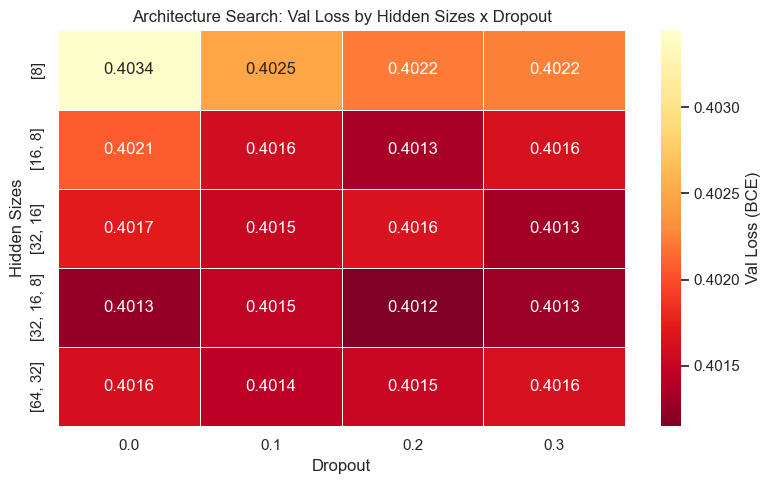

In [6]:
# Build pivot table for heatmap
arch_labels = [str(hs) for hs in arch_configs]
pivot_data = pd.DataFrame(
    {do: [arch_results[(str(hs), do)] for hs in arch_configs] for do in dropout_values},
    index=arch_labels,
)
pivot_data.index.name = "hidden_sizes"
pivot_data.columns.name = "dropout"

fig, ax = plt.subplots(figsize=(8, 5))
sns.heatmap(pivot_data, annot=True, fmt=".4f", cmap="YlOrRd_r", ax=ax,
            linewidths=0.5, cbar_kws={"label": "Val Loss (BCE)"})
ax.set_title("Architecture Search: Val Loss by Hidden Sizes x Dropout")
ax.set_xlabel("Dropout")
ax.set_ylabel("Hidden Sizes")
plt.tight_layout()
plt.show()

## 7. Learning Rate Sweep

In [7]:
lr_values = [1e-4, 5e-4, 1e-3, 3e-3, 1e-2]
lr_curves = {}

for lr in lr_values:
    mlp_lr = GatingMLP(context_X.shape[1], 3, hidden_sizes=best_hidden, dropout=best_dropout)
    opt_lr = torch.optim.Adam(mlp_lr.parameters(), lr=lr)
    vl_curve = []
    best_vl_lr = float('inf')
    best_ep_lr = 0
    for ep in range(GATING_EPOCHS):
        mlp_lr.train()
        w = mlp_lr(ctx_train)
        bl = (w * ep_train).sum(1).clamp(1e-7, 1 - 1e-7)
        loss = criterion(bl, y_train_t)
        opt_lr.zero_grad()
        loss.backward()
        opt_lr.step()
        mlp_lr.eval()
        with torch.no_grad():
            wv = mlp_lr(ctx_val)
            bv = (wv * ep_val).sum(1).clamp(1e-7, 1 - 1e-7)
            vl = criterion(bv, y_val_t).item()
        vl_curve.append(vl)
        if vl < best_vl_lr:
            best_vl_lr = vl
            best_ep_lr = ep
        if ep - best_ep_lr >= patience:
            break
    lr_curves[lr] = vl_curve
    print(f"  LR={lr:.0e} -> best_val_loss={best_vl_lr:.6f} (epoch {best_ep_lr})")

# Identify best LR
best_lr = min(lr_curves, key=lambda lr: min(lr_curves[lr]))
print(f"\nBest LR: {best_lr:.0e}, val_loss={min(lr_curves[best_lr]):.6f}")

  LR=1e-04 -> best_val_loss=0.437116 (epoch 199)
  LR=5e-04 -> best_val_loss=0.401503 (epoch 199)
  LR=1e-03 -> best_val_loss=0.401273 (epoch 199)
  LR=3e-03 -> best_val_loss=0.401242 (epoch 129)
  LR=1e-02 -> best_val_loss=0.401034 (epoch 65)

Best LR: 1e-02, val_loss=0.401034


## 8. Viz: LR Sweep Loss Curves

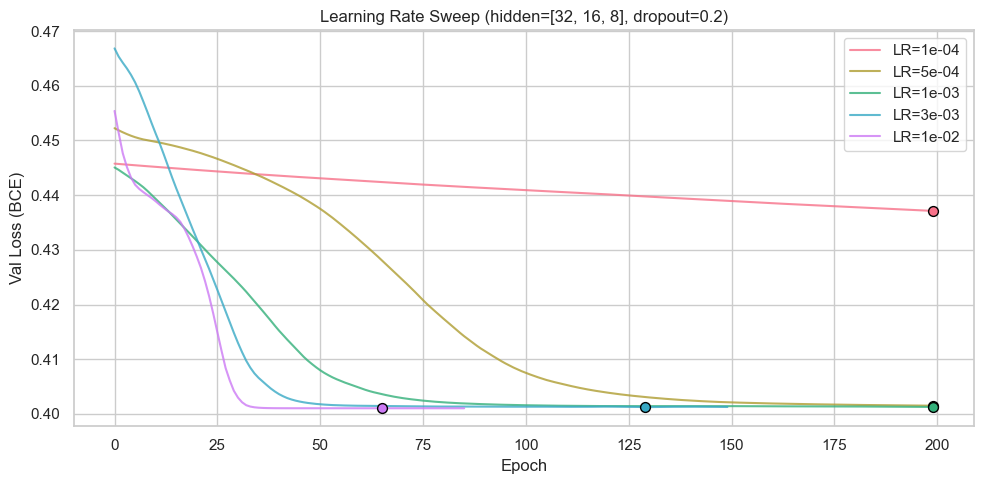

In [8]:
fig, ax = plt.subplots(figsize=(10, 5))
colors = sns.color_palette("husl", len(lr_values))
for i, lr in enumerate(lr_values):
    curve = lr_curves[lr]
    ax.plot(range(len(curve)), curve, label=f"LR={lr:.0e}", color=colors[i], alpha=0.8)
    # Mark the minimum
    min_ep = np.argmin(curve)
    ax.scatter(min_ep, curve[min_ep], color=colors[i], zorder=5, s=50, edgecolors="black")
ax.set_xlabel("Epoch")
ax.set_ylabel("Val Loss (BCE)")
ax.set_title(f"Learning Rate Sweep (hidden={best_hidden}, dropout={best_dropout})")
ax.legend()
plt.tight_layout()
plt.show()

## 9. Expert Weight Analysis

In [9]:
# Train final gating with best hyperparameters found above
gating = GatingNetwork(
    input_dim=context_X.shape[1],
    n_experts=3,
    lr=best_lr,
    epochs=GATING_EPOCHS,
    batch_size=GATING_BATCH_SIZE,
)
gating.fit(context_X, expert_preds, y)

# Get weights on test set
test_weights = gating.predict_weights(test_context_X)
print(f"Test weights shape: {test_weights.shape}")
print(f"Mean weights per expert:")
for i, name in enumerate(EXPERT_TYPES):
    print(f"  {name}: {test_weights[:, i].mean():.4f} +/- {test_weights[:, i].std():.4f}")

# Build a DataFrame for analysis using raw (non-encoded) gating features
weight_df = pd.DataFrame({
    "w_seed": test_weights[:, 0],
    "w_eff": test_weights[:, 1],
    "w_unc": test_weights[:, 2],
    "seed_diff": test_gating_raw["seed_diff"].values,
    "round": test_gating_raw["round"].values,
    "adjem_delta": test_gating_raw["adjem_delta"].values,
    "luck_delta": test_gating_raw["luck_delta"].values,
})

INFO:src.models.gating_network:Early stopping at epoch 23 (patience=20)
INFO:src.models.gating_network:Trained gating network: best_val_loss=-0.1112, epochs=24


Test weights shape: (126, 3)
Mean weights per expert:
  seed_baseline: 0.3849 +/- 0.0101
  efficiency_delta: 0.3264 +/- 0.0105
  uncertainty_calibration: 0.2887 +/- 0.0023


## 10. Viz: Weight Distribution Histograms

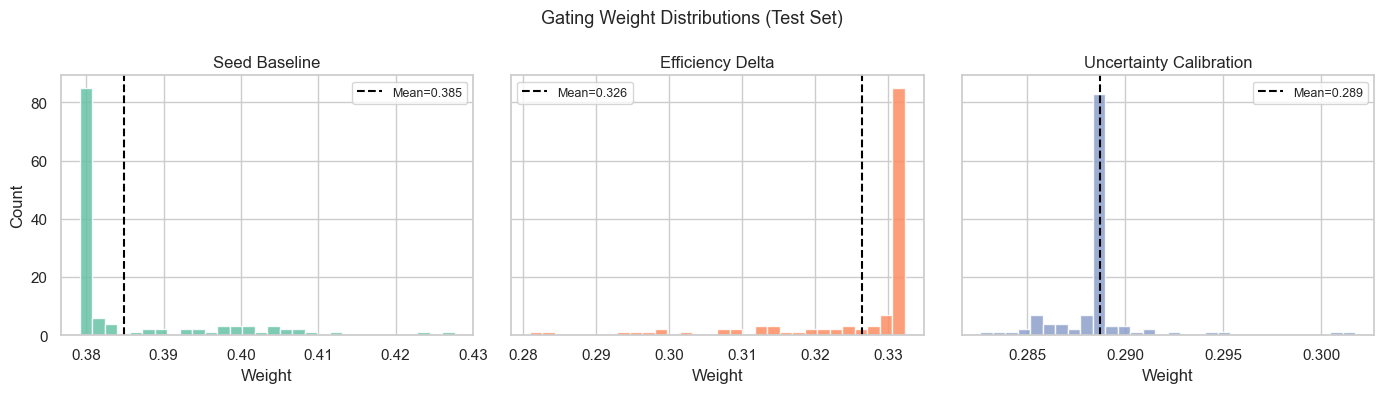

In [10]:
fig, axes = plt.subplots(1, 3, figsize=(14, 4), sharey=True)
weight_cols = ["w_seed", "w_eff", "w_unc"]
expert_labels = ["Seed Baseline", "Efficiency Delta", "Uncertainty Calibration"]
colors = sns.color_palette("Set2", 3)

for i, (col, label) in enumerate(zip(weight_cols, expert_labels)):
    axes[i].hist(weight_df[col], bins=30, color=colors[i], edgecolor="white", alpha=0.85)
    axes[i].axvline(weight_df[col].mean(), color="black", linestyle="--",
                    label=f"Mean={weight_df[col].mean():.3f}")
    axes[i].set_title(label)
    axes[i].set_xlabel("Weight")
    axes[i].legend(fontsize=9)
axes[0].set_ylabel("Count")
fig.suptitle("Gating Weight Distributions (Test Set)", fontsize=13)
plt.tight_layout()
plt.show()

## 11. Viz: Weight by Seed Diff

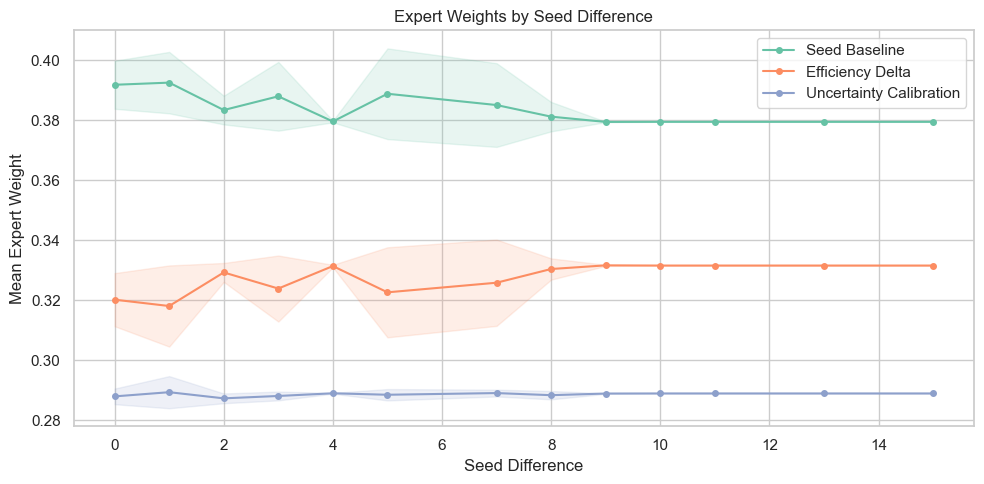

In [11]:
# Group by seed_diff and compute mean +/- std of weights per expert
seed_diffs = sorted(weight_df["seed_diff"].unique())
grouped_sd = weight_df.groupby("seed_diff")[weight_cols].agg(["mean", "std"]).reindex(seed_diffs)

fig, ax = plt.subplots(figsize=(10, 5))
for i, (col, label) in enumerate(zip(weight_cols, expert_labels)):
    mean_vals = grouped_sd[(col, "mean")].values
    std_vals = grouped_sd[(col, "std")].fillna(0).values
    ax.plot(seed_diffs, mean_vals, label=label, color=colors[i], marker="o", markersize=4)
    ax.fill_between(seed_diffs, mean_vals - std_vals, mean_vals + std_vals,
                    color=colors[i], alpha=0.15)
ax.set_xlabel("Seed Difference")
ax.set_ylabel("Mean Expert Weight")
ax.set_title("Expert Weights by Seed Difference")
ax.legend()
plt.tight_layout()
plt.show()

## 12. Viz: Weight by Round

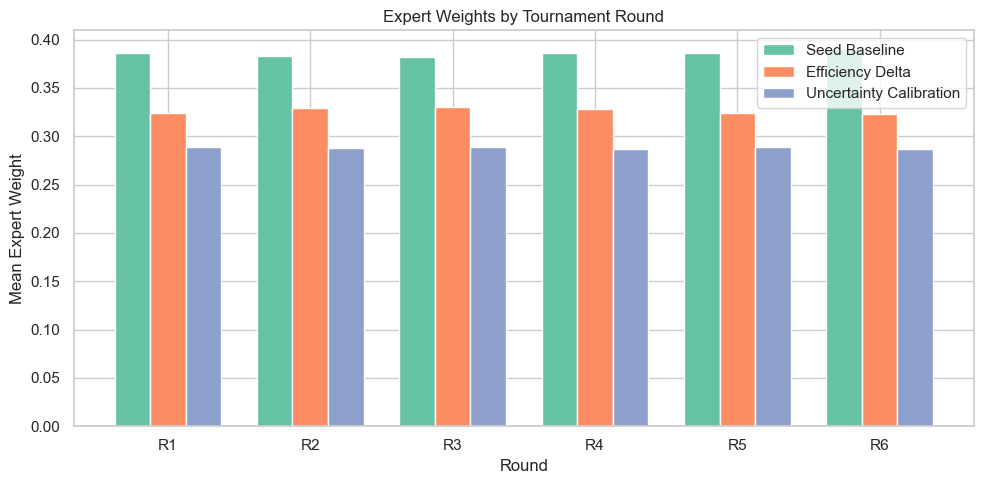

In [12]:
# Grouped bar chart: mean weight per expert by round
round_grouped = weight_df.groupby("round")[weight_cols].mean()
rounds_present = round_grouped.index.astype(int).tolist()

x = np.arange(len(rounds_present))
bar_width = 0.25

fig, ax = plt.subplots(figsize=(10, 5))
for i, (col, label) in enumerate(zip(weight_cols, expert_labels)):
    ax.bar(x + i * bar_width, round_grouped[col].values, bar_width,
           label=label, color=colors[i], edgecolor="white")

ax.set_xlabel("Round")
ax.set_ylabel("Mean Expert Weight")
ax.set_title("Expert Weights by Tournament Round")
ax.set_xticks(x + bar_width)
ax.set_xticklabels([f"R{r}" for r in rounds_present])
ax.legend()
plt.tight_layout()
plt.show()

## 13. Viz: Expert Weight Heatmap (seed_diff x round)

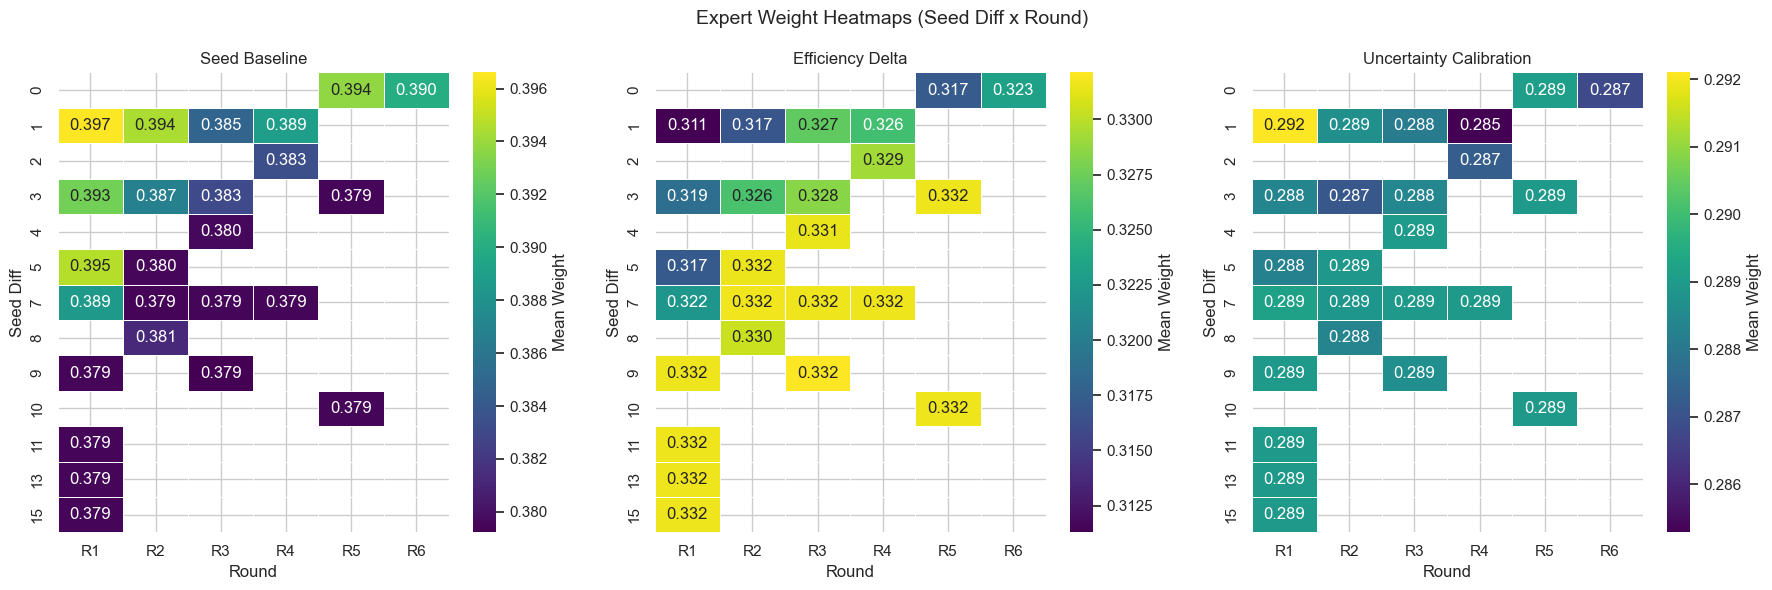

In [13]:
fig, axes = plt.subplots(1, 3, figsize=(18, 6))

for i, (col, label) in enumerate(zip(weight_cols, expert_labels)):
    pivot = weight_df.pivot_table(values=col, index="seed_diff", columns="round", aggfunc="mean")
    pivot.columns = [f"R{int(c)}" for c in pivot.columns]
    sns.heatmap(pivot, annot=True, fmt=".3f", cmap="viridis", ax=axes[i],
                linewidths=0.5, cbar_kws={"label": "Mean Weight"})
    axes[i].set_title(label)
    axes[i].set_xlabel("Round")
    axes[i].set_ylabel("Seed Diff")

fig.suptitle("Expert Weight Heatmaps (Seed Diff x Round)", fontsize=14)
plt.tight_layout()
plt.show()

## 14. Viz: Gating Sensitivity to adjem_delta

/var/folders/wq/qc40qkf92p54dgw397rwdwch0000gn/T/ipykernel_87496/3982937722.py:4: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  adjem_grouped = weight_df.groupby("adjem_delta_decile")[weight_cols].mean().reindex(decile_order)


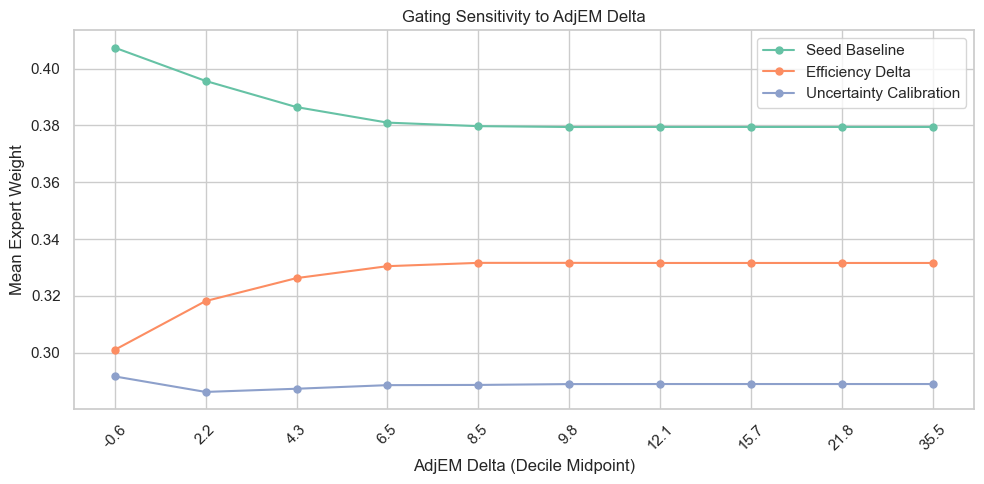

In [14]:
# Bin adjem_delta into deciles and plot mean weight per expert
weight_df["adjem_delta_decile"] = pd.qcut(weight_df["adjem_delta"], q=10, duplicates="drop")
decile_order = sorted(weight_df["adjem_delta_decile"].unique(), key=lambda x: x.mid)
adjem_grouped = weight_df.groupby("adjem_delta_decile")[weight_cols].mean().reindex(decile_order)

fig, ax = plt.subplots(figsize=(10, 5))
x_labels = [f"{interval.mid:.1f}" for interval in adjem_grouped.index]
for i, (col, label) in enumerate(zip(weight_cols, expert_labels)):
    ax.plot(range(len(x_labels)), adjem_grouped[col].values,
            label=label, color=colors[i], marker="o", markersize=5)
ax.set_xticks(range(len(x_labels)))
ax.set_xticklabels(x_labels, rotation=45)
ax.set_xlabel("AdjEM Delta (Decile Midpoint)")
ax.set_ylabel("Mean Expert Weight")
ax.set_title("Gating Sensitivity to AdjEM Delta")
ax.legend()
plt.tight_layout()
plt.show()

## 15. Viz: Gating Sensitivity to luck_delta

/var/folders/wq/qc40qkf92p54dgw397rwdwch0000gn/T/ipykernel_87496/2479669625.py:7: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  luck_grouped = luck_valid.groupby("luck_delta_decile")[weight_cols].mean().reindex(luck_decile_order)


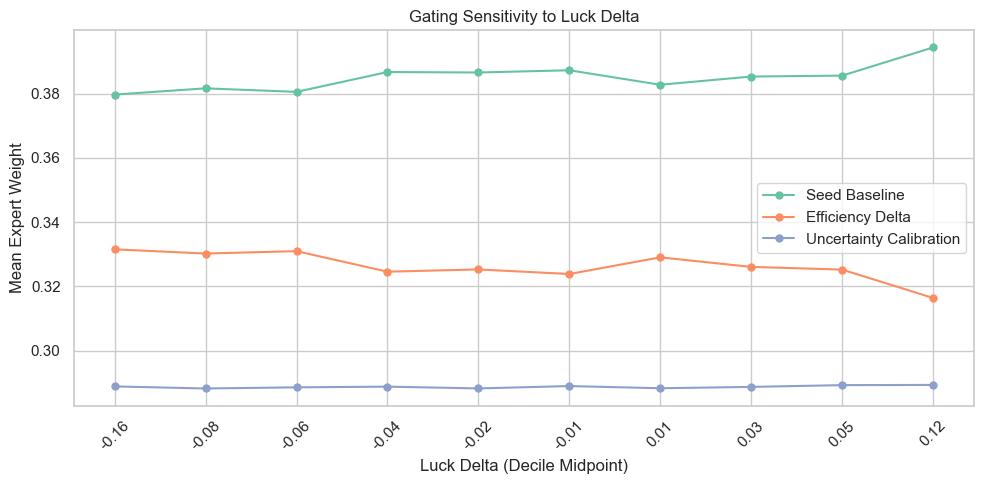

In [15]:
# Bin luck_delta into deciles and plot mean weight per expert
# Drop NaN luck_delta rows before binning (NaN breaks pd.qcut intervals)
luck_valid = weight_df.dropna(subset=["luck_delta"])
luck_valid = luck_valid.copy()
luck_valid["luck_delta_decile"] = pd.qcut(luck_valid["luck_delta"], q=10, duplicates="drop")
luck_decile_order = sorted(luck_valid["luck_delta_decile"].unique(), key=lambda x: x.mid)
luck_grouped = luck_valid.groupby("luck_delta_decile")[weight_cols].mean().reindex(luck_decile_order)

fig, ax = plt.subplots(figsize=(10, 5))
x_labels_luck = [f"{interval.mid:.2f}" for interval in luck_grouped.index]
for i, (col, label) in enumerate(zip(weight_cols, expert_labels)):
    ax.plot(range(len(x_labels_luck)), luck_grouped[col].values,
            label=label, color=colors[i], marker="o", markersize=5)
ax.set_xticks(range(len(x_labels_luck)))
ax.set_xticklabels(x_labels_luck, rotation=45)
ax.set_xlabel("Luck Delta (Decile Midpoint)")
ax.set_ylabel("Mean Expert Weight")
ax.set_title("Gating Sensitivity to Luck Delta")
ax.legend()
plt.tight_layout()
plt.show()

## 16. Gating Effectiveness

In [16]:
# Compare uniform (1/3) weighting vs trained gating on test set
y_test = test_fs.y.values

# Uniform blending
uniform_weights = np.ones_like(test_expert_preds) / 3
uniform_blend = (uniform_weights * test_expert_preds).sum(axis=1)

# Gated blending
gated_blend = (test_weights * test_expert_preds).sum(axis=1)

# Get round info for ESPN score
test_rounds = test_fs.meta["round"].values if "round" in test_fs.meta.columns else None

# Compute metrics
uniform_metrics = compute_all_metrics(y_test, uniform_blend, rounds=test_rounds)
gated_metrics = compute_all_metrics(y_test, gated_blend, rounds=test_rounds)

# Also compute per-expert metrics for reference
expert_metrics = {}
for i, name in enumerate(EXPERT_TYPES):
    expert_metrics[name] = compute_all_metrics(y_test, test_expert_preds[:, i], rounds=test_rounds)

# Display comparison
comparison_rows = []
for name in EXPERT_TYPES:
    comparison_rows.append({"Method": name, **expert_metrics[name]})
comparison_rows.append({"Method": "Uniform (1/3)", **uniform_metrics})
comparison_rows.append({"Method": "Trained Gating", **gated_metrics})

comparison_df = pd.DataFrame(comparison_rows).set_index("Method")
print(comparison_df.to_string())

# Summary
ll_improvement = uniform_metrics["logloss"] - gated_metrics["logloss"]
acc_improvement = gated_metrics["accuracy"] - uniform_metrics["accuracy"]
print(f"\nGating improvement over uniform:")
print(f"  Logloss: {ll_improvement:+.6f} ({'better' if ll_improvement > 0 else 'worse'})")
print(f"  Accuracy: {acc_improvement:+.4f} ({'better' if acc_improvement > 0 else 'worse'})")

                          logloss  accuracy  brier_score  espn_bracket_score
Method                                                                      
seed_baseline            0.345268  0.841270     0.104077              3130.0
efficiency_delta         0.426455  0.777778     0.137219              3040.0
uncertainty_calibration  0.577489  0.746032     0.193918              2940.0
Uniform (1/3)            0.426410  0.857143     0.131303              3280.0
Trained Gating           0.415357  0.865079     0.127204              3300.0

Gating improvement over uniform:
  Logloss: +0.011053 (better)
  Accuracy: +0.0079 (better)


## 17. Viz: Gating Improvement by Context

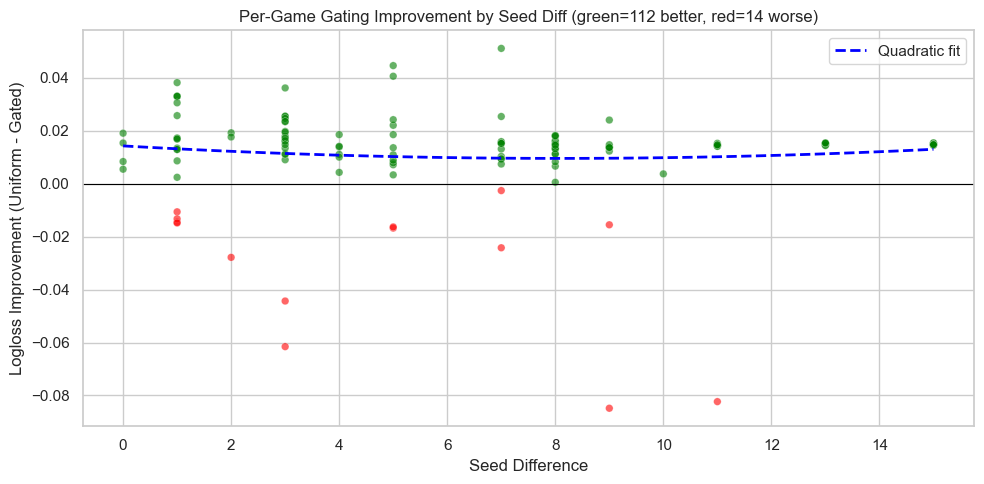

In [17]:
# Per-game logloss improvement: uniform - gated (positive = gating is better)
eps = 1e-15
uniform_clipped = np.clip(uniform_blend, eps, 1 - eps)
gated_clipped = np.clip(gated_blend, eps, 1 - eps)

# Per-game log-loss: -[y*log(p) + (1-y)*log(1-p)]
uniform_per_game = -(y_test * np.log(uniform_clipped) + (1 - y_test) * np.log(1 - uniform_clipped))
gated_per_game = -(y_test * np.log(gated_clipped) + (1 - y_test) * np.log(1 - gated_clipped))
logloss_improvement = uniform_per_game - gated_per_game  # positive = gating better

seed_diff_vals = test_gating_raw["seed_diff"].values

fig, ax = plt.subplots(figsize=(10, 5))
scatter_colors = np.where(logloss_improvement > 0, "green", "red")
ax.scatter(seed_diff_vals, logloss_improvement, c=scatter_colors, alpha=0.6, s=30, edgecolors="white", linewidth=0.3)
ax.axhline(y=0, color="black", linestyle="-", linewidth=0.8)

# Add a trend line
z = np.polyfit(seed_diff_vals, logloss_improvement, 2)
p_fit = np.poly1d(z)
x_range = np.linspace(seed_diff_vals.min(), seed_diff_vals.max(), 100)
ax.plot(x_range, p_fit(x_range), color="blue", linestyle="--", linewidth=2, label="Quadratic fit")

n_better = (logloss_improvement > 0).sum()
n_worse = (logloss_improvement < 0).sum()
ax.set_xlabel("Seed Difference")
ax.set_ylabel("Logloss Improvement (Uniform - Gated)")
ax.set_title(f"Per-Game Gating Improvement by Seed Diff (green={n_better} better, red={n_worse} worse)")
ax.legend()
plt.tight_layout()
plt.show()